<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/26_Introduction_to_Regression_with_statsmodels_in_Python/01_Simple_Linear_Regression_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/taiwan_real_estate2.csv"
# Read the CSV file
taiwan_real_estate = pd.read_csv(url)
display(taiwan_real_estate.head())

# The second URL is not needed for the current task, so I'll remove it
# url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/20_Cleaning_Data_in_Python/dataset/restaurants_L2_dirty.csv"
# try:
#   restaurants_new = pd.read_csv(url)
#   display(restaurants_new.head())
# except Exception as e:
#   print(f"Error reading the second URL as CSV: {e}")

,dist_to_mrt_m,n_convenience,house_age_years,price_twd_msq
0,84.87882,10,30 to 45,11.467474
1,306.59470,9,15 to 30,12.768533
2,561.98450,5,0 to 15,14.311649
3,561.98450,5,0 to 15,16.580938
4,390.56840,5,0 to 15,13.040847


**Which one is the response variable?**  
Regression lets you predict the values of a response variable from known values of explanatory variables. Which variable you use as the response variable depends on the question you are trying to answer, but in many datasets, there will be an obvious choice for variables that would be interesting to predict. Over the next few exercises, you'll explore a Taiwan real estate dataset with four variables.

    Variable	               Meaning
    dist_to_mrt_station_m	Distance to nearest MRT metro station, in meters.
    n_convenience	        No. of convenience stores in walking distance.
    house_age_years	      The age of the house, in years, in three groups.
    price_twd_msq	        House price per unit area, in New Taiwan dollars per meter squared.
Print taiwan_real_estate in the console to view the dataset, and decide which variable would make a good response variable.

- dist_to_mrt_station_m

- n_convenience

- house_age_years

-  --price_twd_msq

**Visualizing two numeric variables**  
Before you can run any statistical models, it's usually a good idea to visualize your dataset. Here, you'll look at the relationship between house price per area and the number of nearby convenience stores using the Taiwan real estate dataset.

One challenge in this dataset is that the number of convenience stores contains integer data, causing points to overlap. To solve this, you will make the points transparent.

`taiwan_real_estate` is available as a pandas DataFrame.

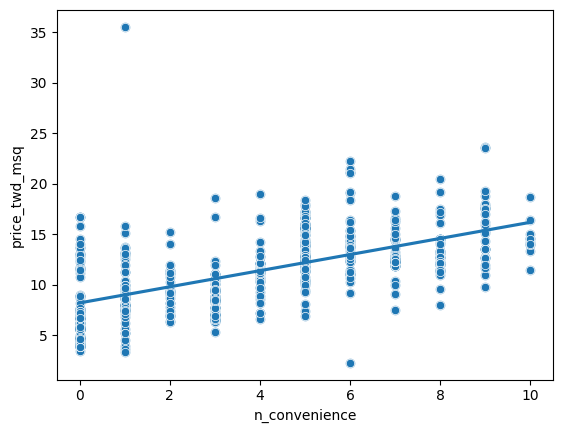

In [3]:
# Import seaborn with alias sns
import seaborn as sns

# Import matplotlib.pyplot with alias plt
import matplotlib.pyplot as plt

# Draw the scatter plot
sns.regplot(x="n_convenience",
            y="price_twd_msq",
            data=taiwan_real_estate,
            ci=None,
            scatter_kws={'alpha': 0.5})

# Draw a trend line on the scatter plot of price_twd_msq vs. n_convenience
sns.scatterplot(x="n_convenience",
                y="price_twd_msq",
                data=taiwan_real_estate,
                )

# Show the plot
plt.show()

**Estimate the intercept**  
Linear regression models always fit a straight line to the data. Straight lines are defined by two properties: their intercept and their slope.

Here, you can see a scatter plot of house price per area versus number of nearby convenience stores, using the Taiwan real estate dataset.

Click the plot, then estimate the intercept of the linear regression trend line.

- 0

- --8.22

- 16.21

[ *t this point, the trend line crosses the y-axis or x = 0.* ]

**Linear regression with ols()**  
While sns.regplot() can display a linear regression trend line, it doesn't give you access to the intercept and slope as variables, or allow you to work with the model results as variables. That means that sometimes you'll need to run a linear regression yourself.

Time to run your first model!

taiwan_real_estate is available. TWD is an abbreviation for Taiwan dollars.

In addition, for this exercise and the remainder of the course, the following packages will be imported and aliased if necessary: matplotlib.pyplot as plt, seaborn as sns, and pandas as pd.

In [7]:
# Import the ols function
from statsmodels.formula.api import ols

# Create the model object
mdl_price_vs_conv = ols('price_twd_msq ~ n_convenience', data=taiwan_real_estate)

# Fit the model
mdl_price_vs_conv = mdl_price_vs_conv.fit()

# Print the parameters of the fitted model
print(mdl_price_vs_conv.params)

Intercept        8.224237
n_convenience    0.798080
dtype: float64


**Visualizing numeric vs. categorical**  
If the explanatory variable is categorical, the scatter plot that you used before to visualize the data doesn't make sense. Instead, a good option is to draw a histogram for each category.

The Taiwan real estate dataset has a categorical variable in the form of the age of each house. The ages have been split into 3 groups: 0 to 15 years, 15 to 30 years, and 30 to 45 years.

taiwan_real_estate is available.

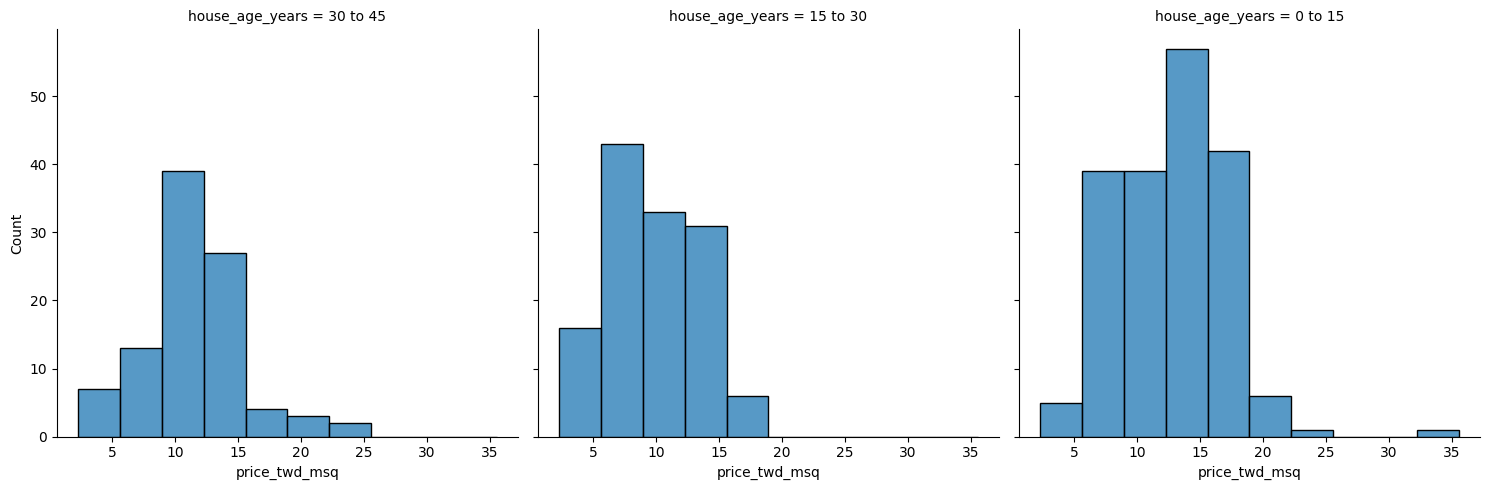

In [4]:
# Histograms of price_twd_msq with 10 bins, split by the age of each house
sns.displot(data=taiwan_real_estate,
            x="price_twd_msq",
            col="house_age_years",
            bins=10)

# Show the plot
plt.show()

# It appears that new houses are the most expensive on average, and the medium aged ones (15 to 30 years) are the cheapest.

**Calculating means by category**  
A good way to explore categorical variables further is to calculate summary statistics for each category. For example, you can calculate the mean and median of your response variable, grouped by a categorical variable. As such, you can compare each category in more detail.

Here, you'll look at grouped means for the house prices in the Taiwan real estate dataset. This will help you understand the output of a linear regression with a categorical variable.

taiwan_real_estate is available as a pandas DataFrame.

In [5]:
# Calculate the mean of price_twd_msq, grouped by house age
mean_price_by_age = taiwan_real_estate.groupby("house_age_years")["price_twd_msq"].mean()

# Print the result
print(mean_price_by_age)

house_age_years
0 to 15     12.637471
15 to 30     9.876743
30 to 45    11.393264
Name: price_twd_msq, dtype: float64


**Linear regression with a categorical explanatory variable**  
Great job calculating those grouped means! As mentioned in the last video, the means of each category will also be the coefficients of a linear regression model with one categorical variable. You'll prove that in this exercise.

To run a linear regression model with categorical explanatory variables, you can use the same code as with numeric explanatory variables. The coefficients returned by the model are different, however. Here you'll run a linear regression on the Taiwan real estate dataset.

taiwan_real_estate is available and the ols() function is also loaded.

In [8]:
# Update the model formula to remove the intercept
mdl_price_vs_age0 = ols("price_twd_msq ~ house_age_years + 0" , data=taiwan_real_estate).fit()

# Print the parameters of the fitted model
print(mdl_price_vs_age0.params)

# Classy categorical linear regression! The coefficients of the model are just the means of each category you calculated previously. Fantastic job!

house_age_years[0 to 15]     12.637471
house_age_years[15 to 30]     9.876743
house_age_years[30 to 45]    11.393264
dtype: float64
